# Student performance | A reproducible analysis

**Research question:** What relationships are visible between study habits, attendance, educational support, and exam performance?

This notebook reproduces the **three original SQL assignment questions** and extends them with more detailed group comparisons, sample sizes, and a simple held-out predictive illustration. The 6,607 observations form a **synthetic, observational dataset**, so these relationships do not establish causality.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "StudentPerformanceFactors.csv").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from scripts.analyze import load, summaries, model
from scripts.run_sql import connection, sqlite_sql
raw, prepared = load()
print(f"Records: {len(raw):,} | Original fields: {len(raw.columns)} | Average score: {raw.Exam_Score.mean():.2f}")
display(raw.head(4))

Records: 6,607 | Original fields: 20 | Average score: 67.24


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71


## 1. Data quality before analysis

We keep the original exam scores intact so the original SQL answers remain reproducible. Three original categorical fields are partially missing and become **Unknown** in the Power BI export. **One score is 101**, which lies outside an expected 0–100 scale; the prepared dataset exposes this with a quality flag and sensitivity comparison.

In [2]:
qa = pd.DataFrame({"missing_raw": raw.isna().sum()}).query("missing_raw > 0")
display(qa)
print("Source scores > 100:", int((raw.Exam_Score > 100).sum()))
print("Average with flagged row:", round(raw.Exam_Score.mean(),4))
print("Average excluding flagged row:", round(raw.loc[raw.Exam_Score <= 100,"Exam_Score"].mean(),4))

,missing_raw
Teacher_Quality,78
Parental_Education_Level,90
Distance_from_Home,67


Source scores > 100: 1
Average with flagged row: 67.2357
Average excluding flagged row: 67.2305


## 2. Original DataCamp questions: run the actual SQL

The SQL files under `sql/` target **PostgreSQL**. Here we run the same logic locally with **SQLite**. The runner only removes PostgreSQL's dialect-specific `::NUMERIC` cast before evaluation. The ranking query never exposes exam scores in its final output.

In [3]:
db = connection()
queries = [
    ("Q1: hours > 10 + extracurricular participation", "01_avg_exam_score_by_study_and_extracurricular.sql", 30),
    ("Q2: study-hour ranges", "02_avg_exam_score_by_hours_studied_range.sql", 4),
    ("Q3: dense exam ranking (top 30)", "03_exam_ranking.sql", 30),
]
for title, filename, expected_count in queries:
    output = pd.read_sql_query(sqlite_sql(filename), db)
    assert len(output) == expected_count
    print(f"\n{title}: {len(output)} output rows")
    display(output.head(5))


Q1: hours > 10 + extracurricular participation: 30 output rows


,hours_studied,avg_exam_score
0,43,78.00
1,39,75.00
2,38,73.50
3,37,73.00
4,36,70.43



Q2: study-hour ranges: 4 output rows


,hours_studied_range,avg_exam_score
0,16+ hours,67.92
1,11-15 hours,65.20
2,6-10 hours,64.23
3,1-5 hours,62.63



Q3: dense exam ranking (top 30): 30 output rows


,attendance,hours_studied,sleep_hours,tutoring_sessions,exam_rank
0,98,27,6,5,1
1,89,18,4,3,2
2,90,14,8,4,3
3,83,23,4,1,3
4,96,28,4,1,4


## 3. The main story: attendance and study hours

Shorter study groups are much smaller, so every visualization and table also shows **the number of records**. The next comparison combines both habits rather than considering them in isolation.

,Study_Hours_Range,students,avg_score,order
0,1-5 hours,59,62.63,1
3,6-10 hours,306,64.23,2
1,11-15 hours,1140,65.20,3
2,16+ hours,5102,67.92,4


,Attendance_Band,students,avg_score,order
0,60-69%,1573,64.21,1
1,70-79%,1681,66.28,2
2,80-89%,1607,68.04,3
3,90-100%,1746,70.14,4


,Study_Group,Attendance_Group,students,avg_score
0,16+ hours,80%+,2577,69.85
1,16+ hours,<80%,2525,65.96
2,<16 hours,80%+,776,66.78
3,<16 hours,<80%,729,62.91


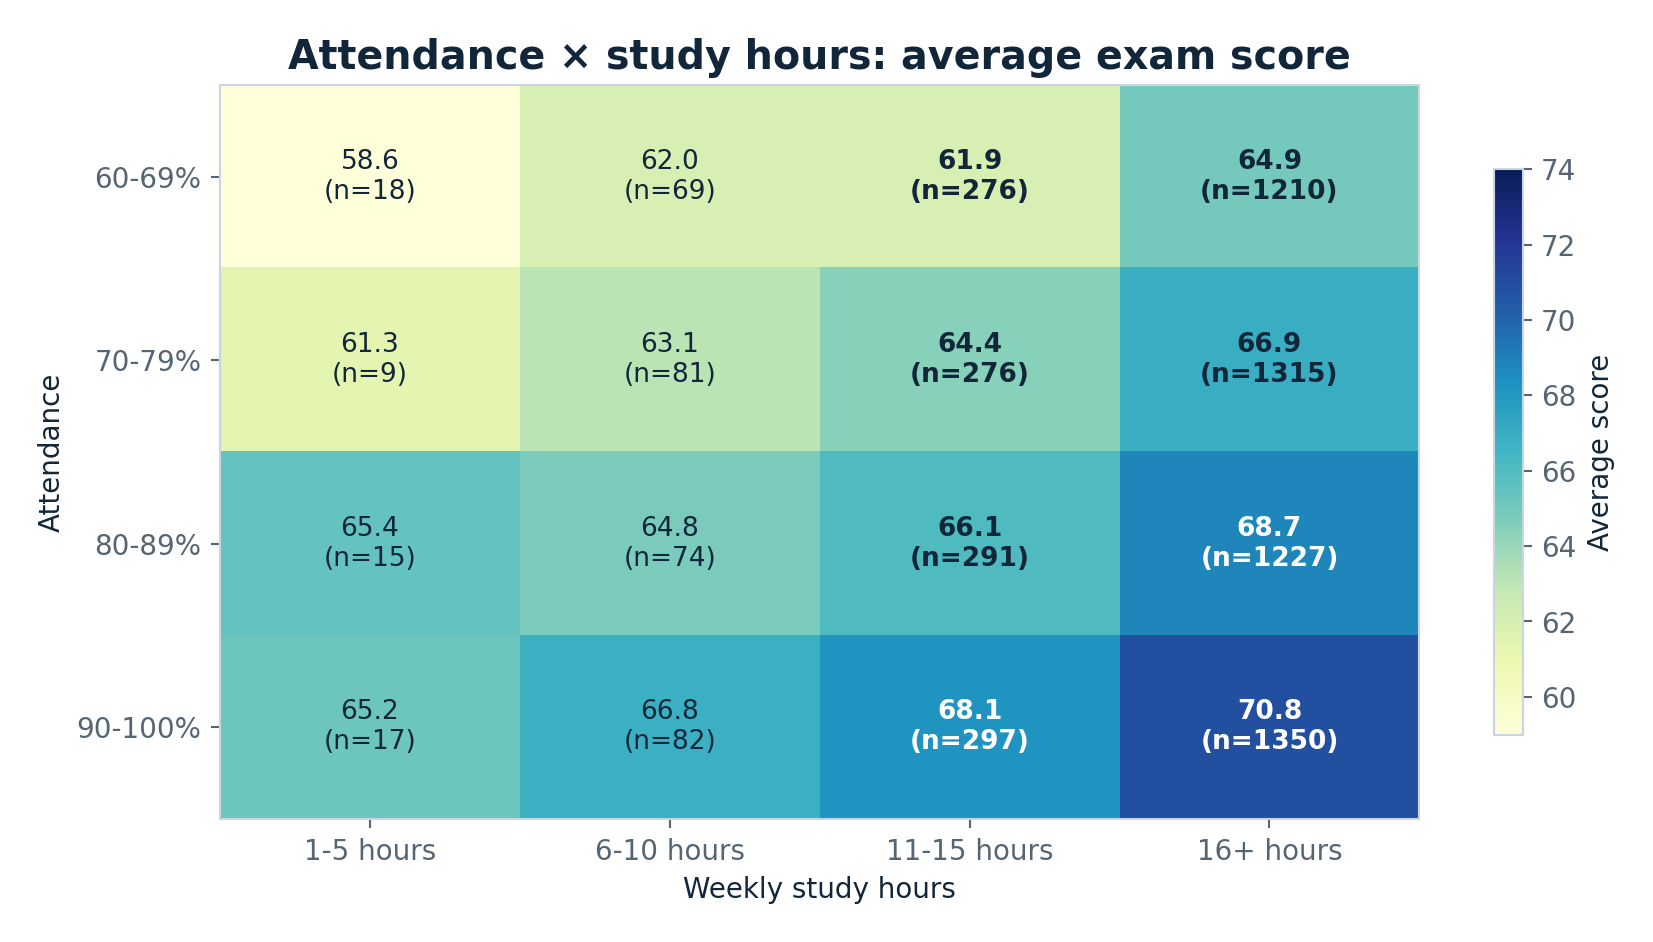

In [4]:
results = summaries(raw, prepared)
display(results["group"].round(2))
display(results["att"].round(2))
display(results["case"].round(2))
display(Image(filename=str(ROOT/"charts"/"03_attendance_study_heatmap.png")))

## 4. Check alternative explanations: tutoring and sleep

The tutoring comparison is **stratified by study hours**; it is still observational and is not a matched trial. Sleep-hour means are nearly flat in this particular dataset; avoid inventing a strong pattern where none appears.

,Study_Hours_Range,Tutoring_Group,students,avg_score,study_order
0,1-5 hours,1+ sessions,50,63.06,1
1,1-5 hours,No tutoring,9,60.22,1
6,6-10 hours,1+ sessions,230,64.51,2
7,6-10 hours,No tutoring,76,63.37,2
2,11-15 hours,1+ sessions,874,65.48,3
3,11-15 hours,No tutoring,266,64.29,3
4,16+ hours,1+ sessions,3940,68.12,4
5,16+ hours,No tutoring,1162,67.25,4


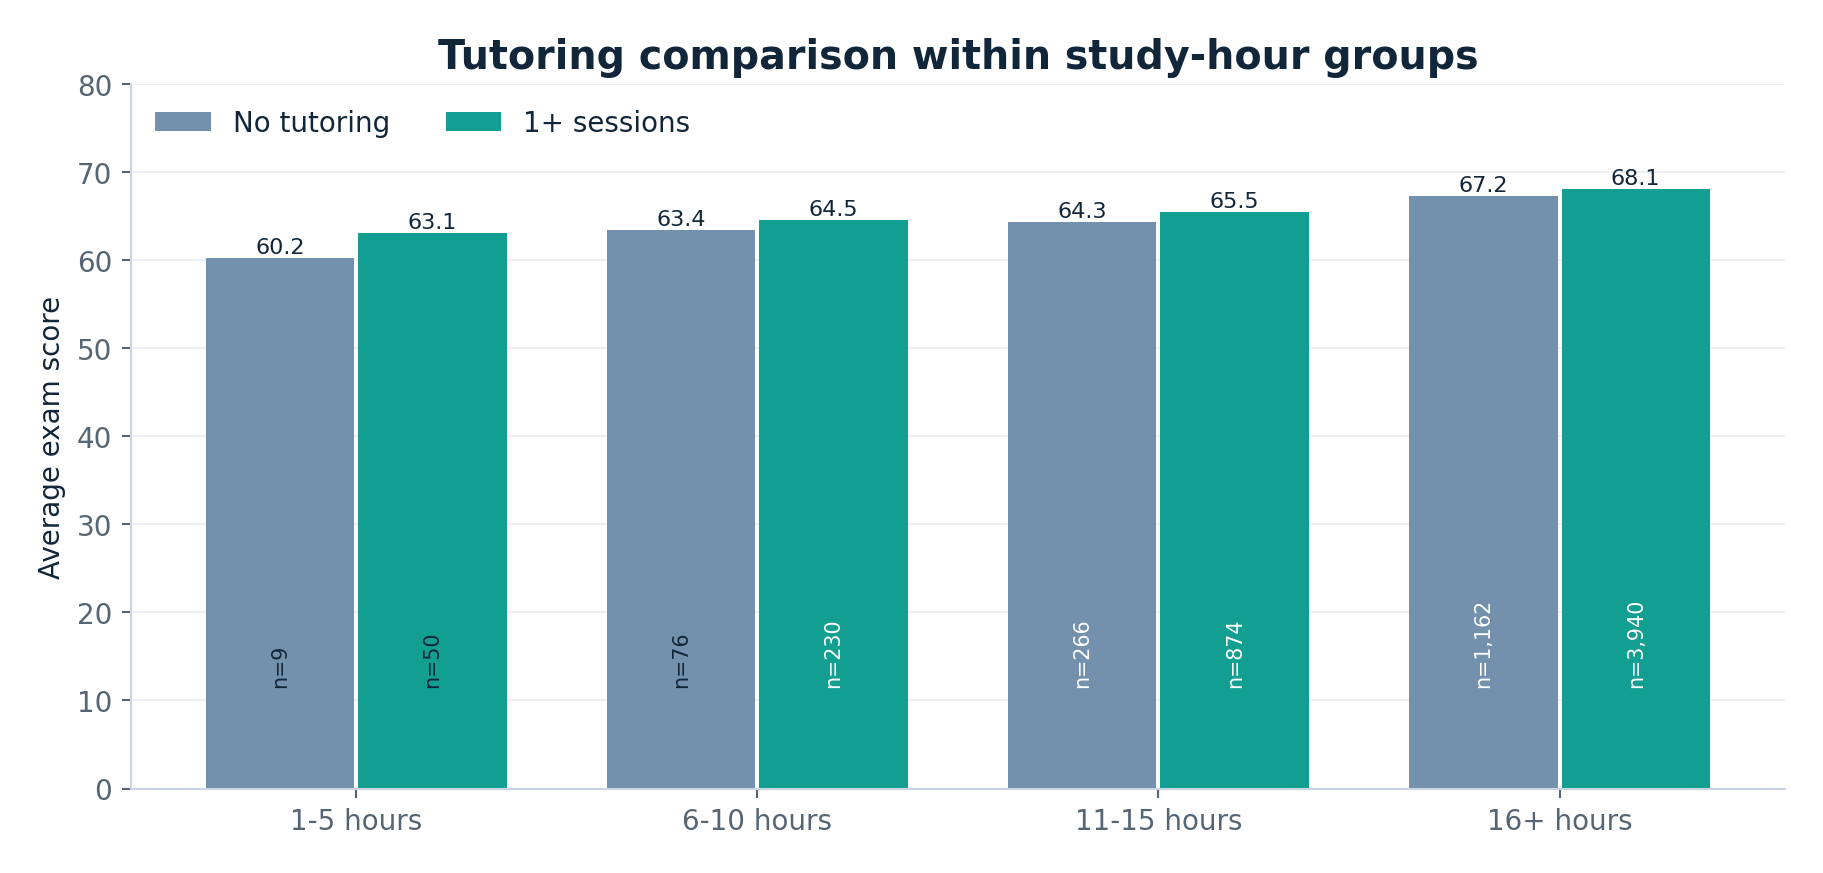

,Sleep_Hours,students,avg_score
0,4,309,67.63
1,5,695,67.30
2,6,1376,67.19
3,7,1741,67.24
4,8,1399,67.22
5,9,775,67.15
6,10,312,67.14


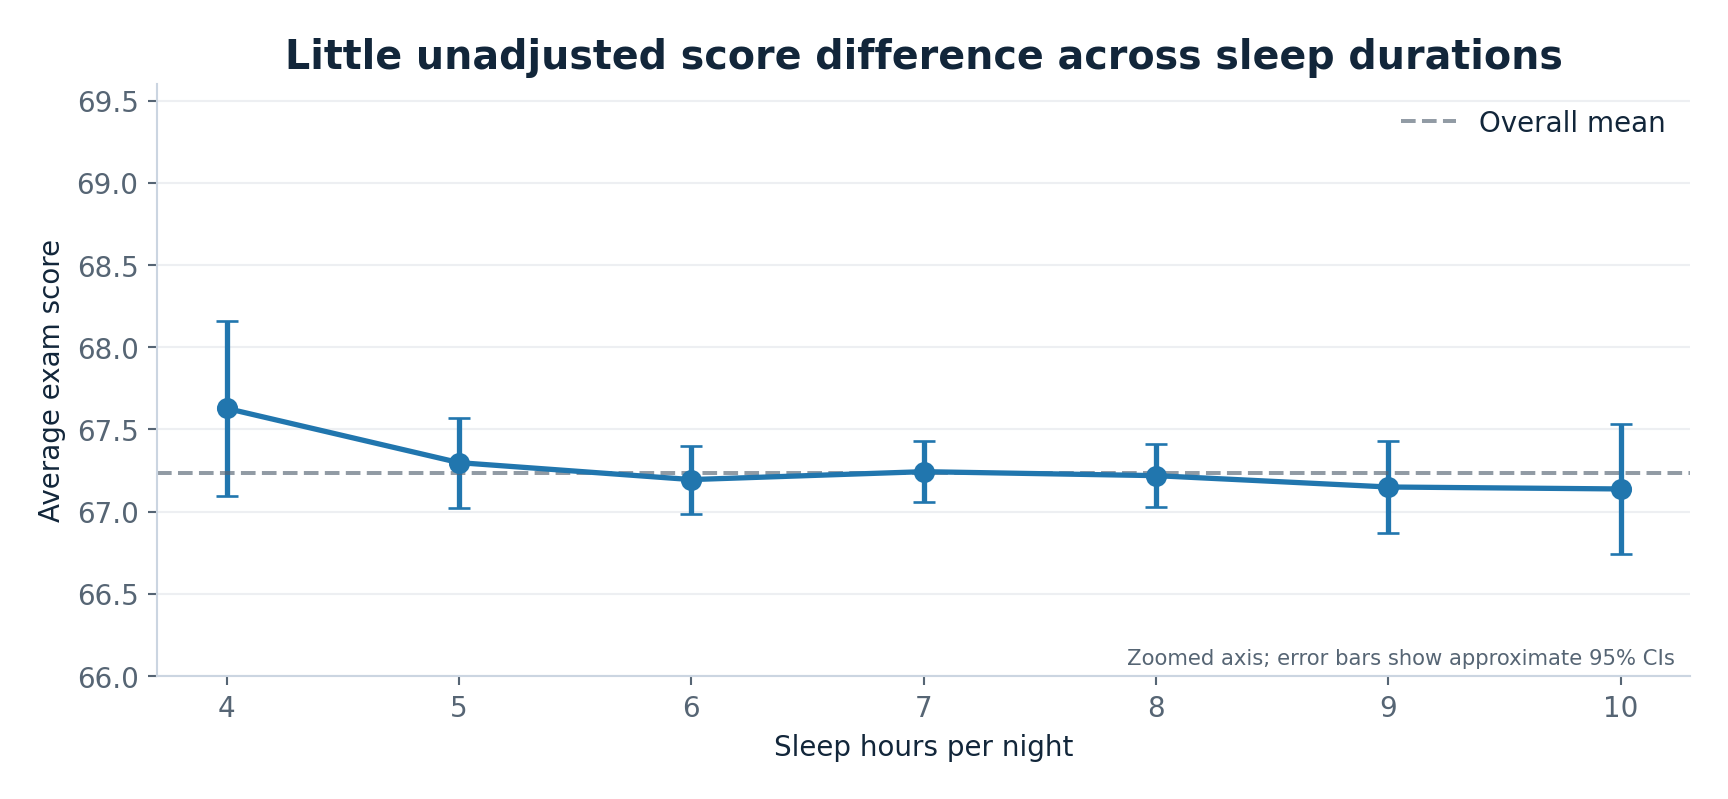

In [5]:
display(results["tutor"].round(2))
display(Image(filename=str(ROOT/"charts"/"04_tutoring.png")))
display(results["sleep"][["Sleep_Hours","students","avg_score"]].round(2))
display(Image(filename=str(ROOT/"charts"/"05_sleep.png")))

## 5. Numerical associations

Pearson's *r* summarizes **linear association** only; it cannot measure causality or isolate overlapping mechanisms. Variable scales, confounders and the synthetic nature of the source limit any generalization.

,Pearson r
Attendance,0.581
Hours_Studied,0.445
Previous_Scores,0.175
Tutoring_Sessions,0.157
Physical_Activity,0.028
Sleep_Hours,-0.017


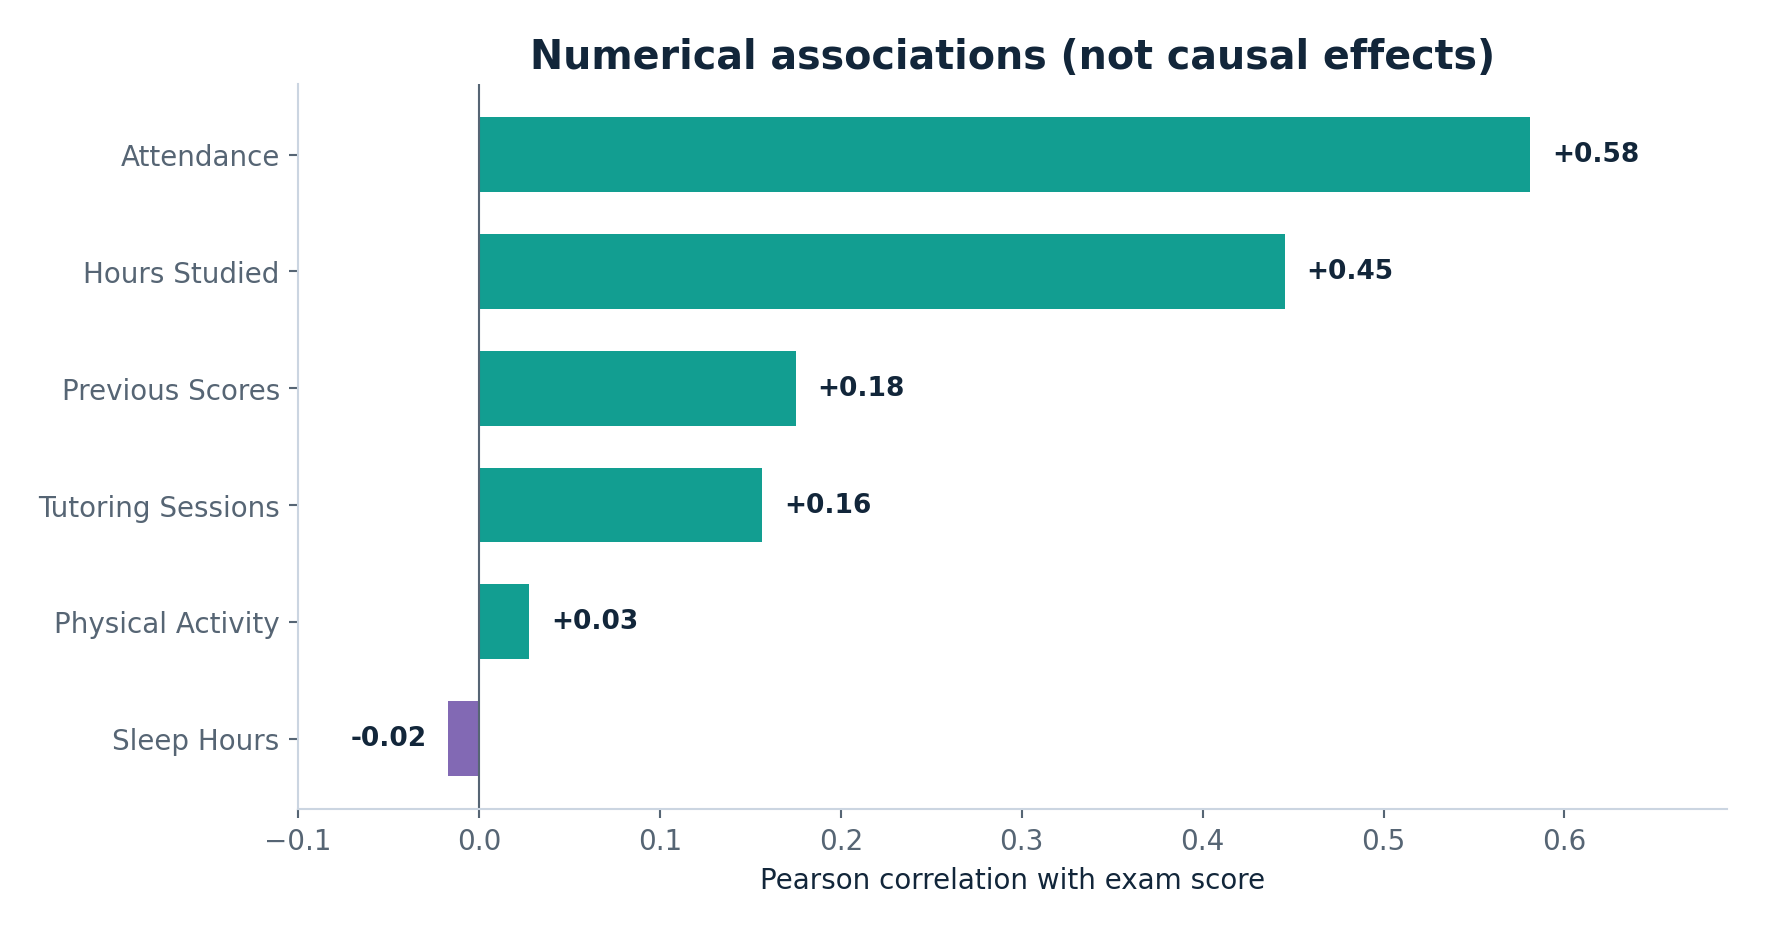

In [6]:
display(results["corr"].rename("Pearson r").to_frame().round(3))
display(Image(filename=str(ROOT/"charts"/"06_correlations.png")))

## 6. Optional predictive demonstration (not for student-level decision-making)

For reproducibility, train/test records are selected with `random_state=42` and an **80/20 random split**. The simple ridge-regression comparison evaluates prediction in held-out rows of this synthetic dataset. Predictive fit is **not** evidence that an input causes an outcome; neither model should be used to assess actual students.

In [7]:
holdout = model(raw)
display(pd.DataFrame(holdout).round(3))
print("Compare these values against results/optional_holdout_model.csv")

,model,train_rows,test_rows,test_mae,test_r2
0,Numeric-only baseline,5285,1322,1.266,0.642
1,Numeric + two categories,5285,1322,1.235,0.650


Compare these values against results/optional_holdout_model.csv


## Conclusion and limitations

- **Attendance and weekly study hours** show clear positive unadjusted associations with score in these records.
- **Tutoring** differences remain visible inside study-hour bins, but many other attributes can differ between the groups.
- **Sleep hours** show little linear correlation with exam scores in these records. This does **not** show that sleep is unimportant in real life.
- Original coursework results deliberately retain the **single score of 101**; data quality is explicit, not silently altered.
- **This synthetic dataset is not a representative causal experiment.** Treat recommendations as hypotheses for further investigation, not policy prescriptions.

The interactive companion is prepared in `powerbi/` with DAX measures, a theme and step-by-step build instructions.